In [123]:
# STEP 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")

# Make results reproducible
np.random.seed(42)

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [124]:
# STEP 2: Define Dataset Columns

# Content performance columns
content_columns = [
    "content_id",
    "topic",
    "content_type",
    "format",
    "hook_type",
    "posting_time",
    "caption_style",
    "video_length_seconds",
    "reach",
    "views",
    "likes",
    "comments",
    "shares",
    "saves",
    "retention_rate",
    "follower_growth"
]

# Audience comment columns
comment_columns = [
    "comment_id",
    "content_id",
    "comment_text"
]

print("Content dataset columns:")
print(content_columns)

print("\nComment dataset columns:")
print(comment_columns)

Content dataset columns:
['content_id', 'topic', 'content_type', 'format', 'hook_type', 'posting_time', 'caption_style', 'video_length_seconds', 'reach', 'views', 'likes', 'comments', 'shares', 'saves', 'retention_rate', 'follower_growth']

Comment dataset columns:
['comment_id', 'content_id', 'comment_text']


In [125]:
# STEP 3: Generate Project Content Performance Dataset

topics = [
    "Social Anxiety",
    "Academic Pressure",
    "Friendship",
    "Dating",
    "Self Confidence",
    "Family Expectations",
    "Loneliness",
    "Work Stress"
]

content_types = [
    "Short Video",
    "Long Video",
    "Image Post",
    "Carousel"
]

formats = ["Short", "Long"]
hook_types = ["Visual", "Text"]
posting_times = ["Morning", "Afternoon", "Evening"]
caption_styles = ["Storytelling", "Question", "Informative", "Emotional"]

topic_factors = {
    "Social Anxiety": 1.30,
    "Academic Pressure": 1.25,
    "Friendship": 1.18,
    "Dating": 1.10,
    "Self Confidence": 1.15,
    "Family Expectations": 1.22,
    "Loneliness": 1.27,
    "Work Stress": 1.08
}

n = 240

content_data = []

for i in range(1, n + 1):
    topic = np.random.choice(topics)
    content_type = np.random.choice(content_types)
    content_format = np.random.choice(formats)
    hook = np.random.choice(hook_types)
    posting_time = np.random.choice(posting_times)
    caption_style = np.random.choice(caption_styles)

    video_length = (
        np.random.randint(15, 61)
        if content_format == "Short"
        else np.random.randint(61, 301)
    )

    reach = np.random.randint(2000, 50001)

    views = int(
        reach
        * np.random.uniform(0.55, 0.95)
        * topic_factors[topic]
    )

    likes = int(views * np.random.uniform(0.04, 0.12))
    comments = int(views * np.random.uniform(0.005, 0.025))
    shares = int(views * np.random.uniform(0.01, 0.06))
    saves = int(views * np.random.uniform(0.01, 0.05))

    if content_format == "Short":
        retention_rate = np.random.uniform(45, 95)
    else:
        retention_rate = np.random.uniform(30, 85)

    follower_growth = int(
        shares * 0.08
        + saves * 0.06
        + comments * 0.04
        + np.random.randint(5, 101)
    )

    content_data.append([
        f"C{i:03d}",
        topic,
        content_type,
        content_format,
        hook,
        posting_time,
        caption_style,
        video_length,
        reach,
        views,
        likes,
        comments,
        shares,
        saves,
        retention_rate,
        follower_growth
    ])

content_df = pd.DataFrame(
    content_data,
    columns=content_columns
)

print("Dataset created successfully!")
print("Number of records:", len(content_df))
print("Number of columns:", len(content_df.columns))

display(content_df.head())

Dataset created successfully!
Number of records: 240
Number of columns: 16


,content_id,topic,content_type,format,hook_type,posting_time,caption_style,video_length_seconds,reach,views,likes,comments,shares,saves,retention_rate,follower_growth
0,C001,Loneliness,Carousel,Short,Visual,Evening,Emotional,35,8265,6428,286,143,257,246,46.029225,47
1,C002,Work Stress,Carousel,Long,Text,Afternoon,Emotional,248,41188,35452,3152,182,395,1098,51.992353,200
2,C003,Dating,Carousel,Short,Text,Afternoon,Informative,58,3267,2828,123,48,52,35,92.444277,72
3,C004,Family Expectations,Long Video,Long,Visual,Afternoon,Storytelling,190,25483,18616,1482,105,1032,378,66.438726,115
4,C005,Family Expectations,Long Video,Long,Text,Afternoon,Storytelling,251,8873,7901,565,185,366,182,61.374419,113


In [126]:
# STEP 4: Clean the Dataset

clean_df = content_df.copy()

# Check duplicates
print("Duplicate rows before cleaning:", clean_df.duplicated().sum())

# Check missing values
print("\nMissing values before cleaning:")
print(clean_df.isnull().sum())

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Fill missing numerical values with median
numeric_columns = clean_df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Fill missing categorical values with mode
categorical_columns = clean_df.select_dtypes(include="object").columns

for col in categorical_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

# Ensure numerical performance values are non-negative
performance_columns = [
    "reach",
    "views",
    "likes",
    "comments",
    "shares",
    "saves",
    "follower_growth"
]

for col in performance_columns:
    clean_df[col] = clean_df[col].clip(lower=0)

# Keep retention rate between 0 and 100
clean_df["retention_rate"] = clean_df["retention_rate"].clip(0, 100)

# Make sure engagement counts do not exceed views
engagement_columns = ["likes", "comments", "shares", "saves"]

for col in engagement_columns:
    clean_df[col] = np.minimum(clean_df[col], clean_df["views"])

clean_df = clean_df.reset_index(drop=True)

# Save cleaned dataset
clean_df.to_csv(
    "cleaned_content_performance_dataset.csv",
    index=False
)

print("\nCleaning completed successfully!")
print("Final dataset shape:", clean_df.shape)

display(clean_df.head())

Duplicate rows before cleaning: 0

Missing values before cleaning:
content_id              0
topic                   0
content_type            0
format                  0
hook_type               0
posting_time            0
caption_style           0
video_length_seconds    0
reach                   0
views                   0
likes                   0
comments                0
shares                  0
saves                   0
retention_rate          0
follower_growth         0
dtype: int64

Cleaning completed successfully!
Final dataset shape: (240, 16)


,content_id,topic,content_type,format,hook_type,posting_time,caption_style,video_length_seconds,reach,views,likes,comments,shares,saves,retention_rate,follower_growth
0,C001,Loneliness,Carousel,Short,Visual,Evening,Emotional,35,8265,6428,286,143,257,246,46.029225,47
1,C002,Work Stress,Carousel,Long,Text,Afternoon,Emotional,248,41188,35452,3152,182,395,1098,51.992353,200
2,C003,Dating,Carousel,Short,Text,Afternoon,Informative,58,3267,2828,123,48,52,35,92.444277,72
3,C004,Family Expectations,Long Video,Long,Visual,Afternoon,Storytelling,190,25483,18616,1482,105,1032,378,66.438726,115
4,C005,Family Expectations,Long Video,Long,Text,Afternoon,Storytelling,251,8873,7901,565,185,366,182,61.374419,113


Overall Dataset Performance
---------------------------
Average Reach: 26400.48
Average Views: 23827.76
Average Likes: 1967.78
Average Comments: 356.91
Average Shares: 850.08
Average Saves: 694.1
Average Retention Rate: 63.85
Total Follower Growth: 42418

Topic-wise Engagement Rate:


,Average Engagement Rate (%)
topic,
Social Anxiety,16.216743
Academic Pressure,14.822943
Loneliness,14.770460
Friendship,14.438775
Self Confidence,14.333261
Dating,13.915387
Family Expectations,13.796430
Work Stress,13.260474


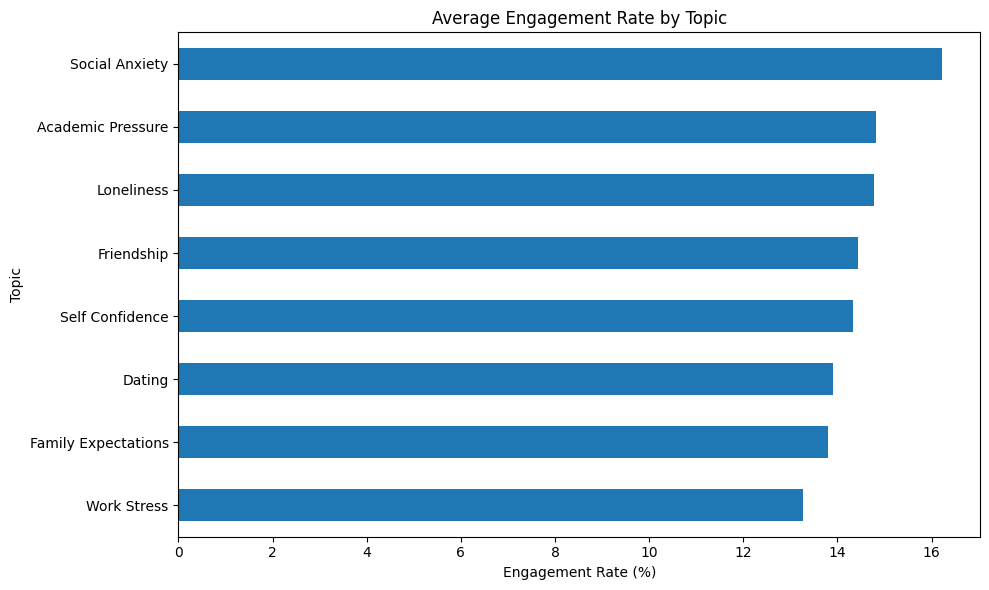

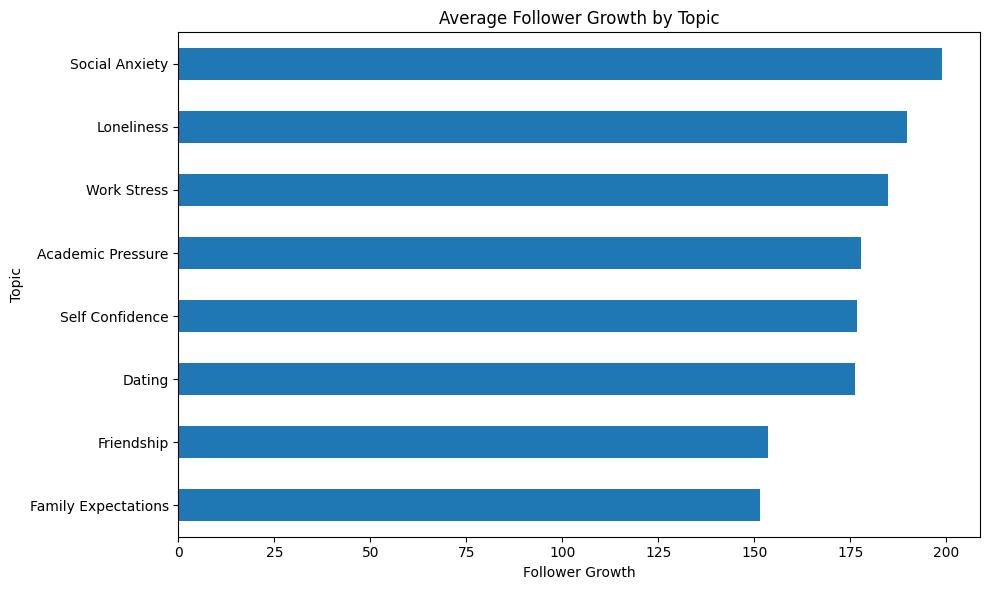


EDA completed successfully!


In [127]:
# STEP 5: Exploratory Data Analysis (EDA)

# Calculate overall performance metrics
print("Overall Dataset Performance")
print("---------------------------")
print("Average Reach:", round(clean_df["reach"].mean(), 2))
print("Average Views:", round(clean_df["views"].mean(), 2))
print("Average Likes:", round(clean_df["likes"].mean(), 2))
print("Average Comments:", round(clean_df["comments"].mean(), 2))
print("Average Shares:", round(clean_df["shares"].mean(), 2))
print("Average Saves:", round(clean_df["saves"].mean(), 2))
print("Average Retention Rate:", round(clean_df["retention_rate"].mean(), 2))
print("Total Follower Growth:", clean_df["follower_growth"].sum())

# Topic-wise performance
topic_performance = clean_df.groupby("topic").agg({
    "reach": "mean",
    "views": "mean",
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "saves": "mean",
    "retention_rate": "mean",
    "follower_growth": "mean"
}).round(2)

# Engagement rate
clean_df["engagement_rate"] = (
    (
        clean_df["likes"]
        + clean_df["comments"]
        + clean_df["shares"]
        + clean_df["saves"]
    )
    / clean_df["reach"]
) * 100

topic_engagement = (
    clean_df.groupby("topic")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTopic-wise Engagement Rate:")
display(topic_engagement.to_frame("Average Engagement Rate (%)"))

# Plot engagement rate by topic
plt.figure(figsize=(10, 6))
topic_engagement.sort_values().plot(kind="barh")
plt.title("Average Engagement Rate by Topic")
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

# Plot follower growth by topic
topic_growth = (
    clean_df.groupby("topic")["follower_growth"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
topic_growth.sort_values().plot(kind="barh")
plt.title("Average Follower Growth by Topic")
plt.xlabel("Follower Growth")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

print("\nEDA completed successfully!")

Average Viral Coefficient by Topic:


,Average Viral Coefficient
topic,
Social Anxiety,0.227683
Academic Pressure,0.215583
Loneliness,0.210963
Self Confidence,0.203832
Friendship,0.203332
Dating,0.193594
Family Expectations,0.188636
Work Stress,0.181671


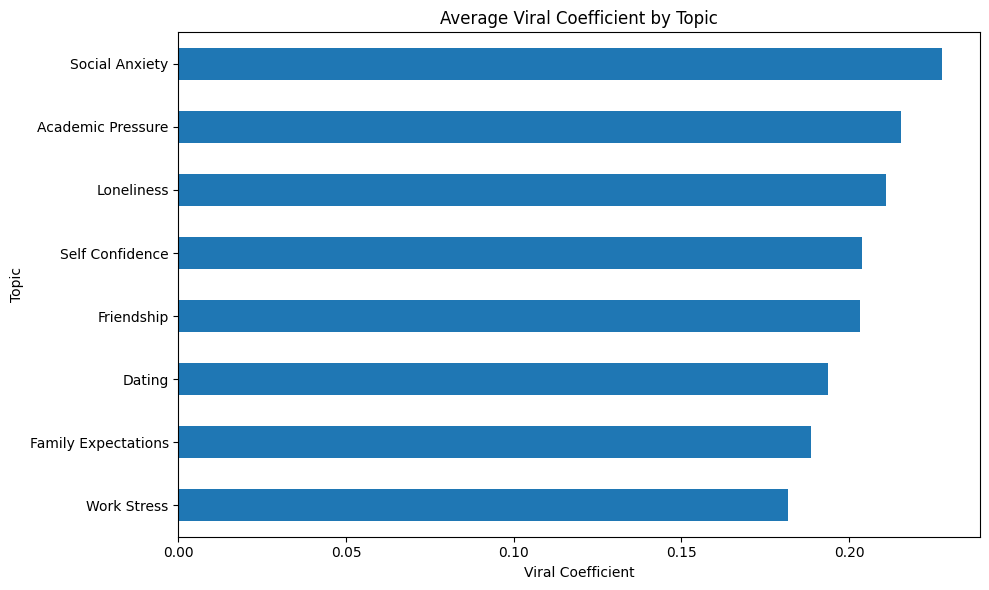


Top 10 Most Viral Content:


,content_id,topic,content_type,format,shares,saves,retention_rate,viral_coefficient,viral_score
86,C087,Friendship,Short Video,Short,1619,728,92.704347,0.322891,29.933370
235,C236,Social Anxiety,Carousel,Short,1157,1156,80.127025,0.350947,28.120323
210,C211,Friendship,Long Video,Short,1052,1015,86.000631,0.310135,26.671815
230,C231,Social Anxiety,Long Video,Short,1531,808,86.071600,0.302834,26.065412
79,C080,Friendship,Image Post,Short,468,461,75.159870,0.342754,25.761343
219,C220,Loneliness,Carousel,Short,2413,1828,76.170298,0.334016,25.442128
102,C103,Academic Pressure,Carousel,Short,170,112,88.408040,0.280702,24.816292
220,C221,Academic Pressure,Image Post,Short,907,723,81.107162,0.299045,24.254661
225,C226,Family Expectations,Image Post,Short,1207,215,94.891043,0.254373,24.137676
150,C151,Social Anxiety,Image Post,Short,190,509,91.137860,0.264376,24.094699



Virality analysis completed successfully!


In [128]:
# STEP 6: Virality Prediction Engine

# Calculate Viral Coefficient
clean_df["viral_coefficient"] = (
    (
        (clean_df["shares"] * 3)
        + (clean_df["saves"] * 2)
        + (clean_df["comments"] * 1.5)
        + (clean_df["likes"] * 0.5)
    )
    / clean_df["reach"]
)

# Combine virality with retention
clean_df["viral_score"] = (
    clean_df["viral_coefficient"]
    * clean_df["retention_rate"]
)

# Topic-wise virality
topic_virality = (
    clean_df.groupby("topic")["viral_coefficient"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Viral Coefficient by Topic:")
display(topic_virality.to_frame("Average Viral Coefficient"))

# Plot virality by topic
plt.figure(figsize=(10, 6))
topic_virality.sort_values().plot(kind="barh")
plt.title("Average Viral Coefficient by Topic")
plt.xlabel("Viral Coefficient")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

# Show top 10 viral content pieces
top_viral_content = clean_df[
    [
        "content_id",
        "topic",
        "content_type",
        "format",
        "shares",
        "saves",
        "retention_rate",
        "viral_coefficient",
        "viral_score"
    ]
].sort_values(
    "viral_score",
    ascending=False
).head(10)

print("\nTop 10 Most Viral Content:")
display(top_viral_content)

# Save updated dataset
clean_df.to_csv(
    "cleaned_content_performance_with_virality.csv",
    index=False
)

print("\nVirality analysis completed successfully!")

In [129]:
# STEP 7: Create Audience Comments Dataset

relatable_comments = [
    "I thought I was the only one feeling this way",
    "This is exactly what I am going through",
    "I can relate to this so much",
    "This describes my life perfectly",
    "I needed to hear this today",
    "Finally someone said this",
    "This is literally me",
    "I have been feeling the same thing",
    "This hit way too close to home",
    "I feel understood",
    "This is so relatable",
    "I thought I was alone in this",
    "You explained exactly how I feel",
    "This describes my situation",
    "I have experienced this too",
    "This made me feel less alone",
    "I completely understand this feeling",
    "This is exactly my experience",
    "I have been through the same thing",
    "This really speaks to me"
]

neutral_comments = [
    "The video was uploaded today",
    "The information is presented clearly",
    "The background music is pleasant",
    "The video has good quality",
    "I watched the entire video",
    "The editing is simple",
    "The colors look nice",
    "The explanation is clear",
    "This is an interesting topic",
    "The video is well made",
    "The presentation looks good",
    "The caption is informative",
    "The audio quality is good",
    "The visuals are clear",
    "The post contains useful information",
    "The video is short",
    "The content is easy to understand",
    "The formatting looks clean",
    "The topic is interesting",
    "The post is informative"
]

comment_records = []

comment_id = 1

for _, row in clean_df.iterrows():

    # One relatable comment
    relatable_text = np.random.choice(relatable_comments)

    comment_records.append([
        f"CM{comment_id:03d}",
        row["content_id"],
        relatable_text,
        "Relatable"
    ])

    comment_id += 1

    # One neutral comment
    neutral_text = np.random.choice(neutral_comments)

    comment_records.append([
        f"CM{comment_id:03d}",
        row["content_id"],
        neutral_text,
        "Neutral"
    ])

    comment_id += 1

comments_df = pd.DataFrame(
    comment_records,
    columns=[
        "comment_id",
        "content_id",
        "comment_text",
        "label"
    ]
)

# Clean comment text
comments_df["clean_text"] = (
    comments_df["comment_text"]
    .str.lower()
    .str.replace(r"http\S+|www\S+", "", regex=True)
    .str.replace(r"[^a-z\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Save dataset
comments_df.to_csv(
    "structured_user_comments_dataset.csv",
    index=False
)

print("Comment dataset created successfully!")
print("Total comments:", len(comments_df))

print("\nLabel distribution:")
print(comments_df["label"].value_counts())

display(comments_df.head(10))

Comment dataset created successfully!
Total comments: 480

Label distribution:
label
Relatable    240
Neutral      240
Name: count, dtype: int64


,comment_id,content_id,comment_text,label,clean_text
0,CM001,C001,This is exactly what I am going through,Relatable,this is exactly what i am going through
1,CM002,C001,The content is easy to understand,Neutral,the content is easy to understand
2,CM003,C002,This describes my life perfectly,Relatable,this describes my life perfectly
3,CM004,C002,The visuals are clear,Neutral,the visuals are clear
4,CM005,C003,I feel understood,Relatable,i feel understood
5,CM006,C003,The background music is pleasant,Neutral,the background music is pleasant
6,CM007,C004,I can relate to this so much,Relatable,i can relate to this so much
7,CM008,C004,The post contains useful information,Neutral,the post contains useful information
8,CM009,C005,Finally someone said this,Relatable,finally someone said this
9,CM010,C005,The content is easy to understand,Neutral,the content is easy to understand


NLP Model Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00        48
   Relatable       1.00      1.00      1.00        48

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



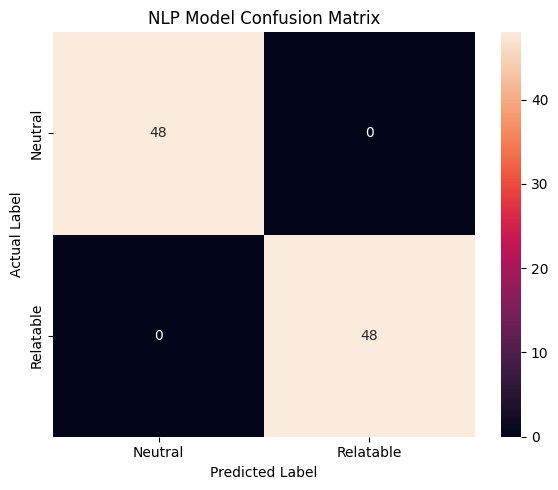


NLP model saved successfully!

Test Predictions:
I feel exactly the same way -> Relatable
The video quality is good -> Neutral
This describes my life -> Relatable
The information is clear -> Neutral
I thought I was alone in this -> Relatable


In [130]:
# STEP 8: Train the NLP Relatability Model

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Features and target
X = comments_df["clean_text"]
y = comments_df["label"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=1000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic Regression model
nlp_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

nlp_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = nlp_model.predict(X_test_tfidf)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("NLP Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Neutral", "Relatable"],
    yticklabels=["Neutral", "Relatable"]
)
plt.title("NLP Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Save model and vectorizer
joblib.dump(nlp_model, "relatability_nlp_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\nNLP model saved successfully!")

# Test the model with new comments
test_comments = [
    "I feel exactly the same way",
    "The video quality is good",
    "This describes my life",
    "The information is clear",
    "I thought I was alone in this"
]

test_vectors = tfidf.transform(test_comments)
test_predictions = nlp_model.predict(test_vectors)

print("\nTest Predictions:")
for comment, prediction in zip(test_comments, test_predictions):
    print(f"{comment} -> {prediction}")

A/B Test: Short vs Long Content
--------------------------------
Short Content Average Engagement: 14.88 %
Long Content Average Engagement: 14.07 %
T-statistic: 1.8094
P-value: 0.0717
Result: No statistically significant difference


<Figure size 800x500 with 0 Axes>

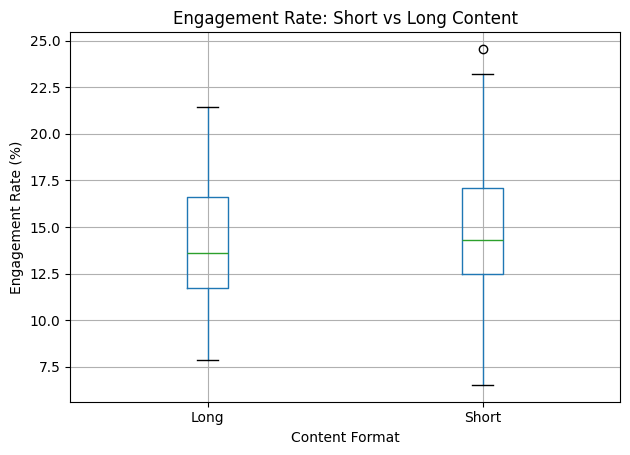

In [131]:
# STEP 9: A/B Testing - Short vs Long Content

from scipy import stats

# Separate engagement rates
short_engagement = clean_df[
    clean_df["format"] == "Short"
]["engagement_rate"]

long_engagement = clean_df[
    clean_df["format"] == "Long"
]["engagement_rate"]

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(
    short_engagement,
    long_engagement,
    equal_var=False
)

print("A/B Test: Short vs Long Content")
print("--------------------------------")
print("Short Content Average Engagement:",
      round(short_engagement.mean(), 2), "%")

print("Long Content Average Engagement:",
      round(long_engagement.mean(), 2), "%")

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Statistically significant difference")
else:
    print("Result: No statistically significant difference")

# Visualization
plt.figure(figsize=(8, 5))

clean_df.boxplot(
    column="engagement_rate",
    by="format"
)

plt.title("Engagement Rate: Short vs Long Content")
plt.suptitle("")
plt.xlabel("Content Format")
plt.ylabel("Engagement Rate (%)")
plt.tight_layout()
plt.show()

A/B Test: Visual vs Text Hooks
--------------------------------
Visual Hook Average Engagement: 14.85 %
Text Hook Average Engagement: 14.21 %
T-statistic: 1.4209
P-value: 0.1567
Result: No statistically significant difference


<Figure size 800x500 with 0 Axes>

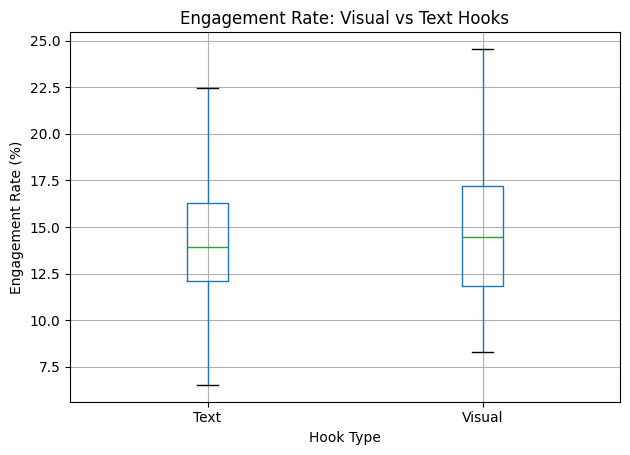

In [132]:
# STEP 10: A/B Testing - Visual vs Text Hooks

visual_engagement = clean_df[
    clean_df["hook_type"] == "Visual"
]["engagement_rate"]

text_engagement = clean_df[
    clean_df["hook_type"] == "Text"
]["engagement_rate"]

# Independent samples t-test
t_stat_hook, p_value_hook = stats.ttest_ind(
    visual_engagement,
    text_engagement,
    equal_var=False
)

print("A/B Test: Visual vs Text Hooks")
print("--------------------------------")
print(
    "Visual Hook Average Engagement:",
    round(visual_engagement.mean(), 2),
    "%"
)

print(
    "Text Hook Average Engagement:",
    round(text_engagement.mean(), 2),
    "%"
)

print("T-statistic:", round(t_stat_hook, 4))
print("P-value:", round(p_value_hook, 4))

if p_value_hook < 0.05:
    print("Result: Statistically significant difference")
else:
    print("Result: No statistically significant difference")

# Visualization
plt.figure(figsize=(8, 5))

clean_df.boxplot(
    column="engagement_rate",
    by="hook_type"
)

plt.title("Engagement Rate: Visual vs Text Hooks")
plt.suptitle("")
plt.xlabel("Hook Type")
plt.ylabel("Engagement Rate (%)")
plt.tight_layout()
plt.show()

A/B Test: Posting Time
----------------------
Morning Average Engagement: 14.21 %
Afternoon Average Engagement: 15.04 %
Evening Average Engagement: 14.21 %
F-statistic: 1.5741
P-value: 0.2093
Result: No statistically significant difference


<Figure size 800x500 with 0 Axes>

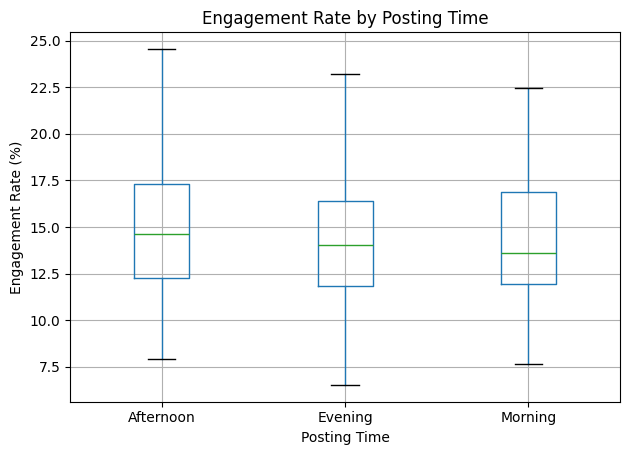

In [133]:
# STEP 11: A/B Testing - Posting Time

morning_engagement = clean_df[
    clean_df["posting_time"] == "Morning"
]["engagement_rate"]

afternoon_engagement = clean_df[
    clean_df["posting_time"] == "Afternoon"
]["engagement_rate"]

evening_engagement = clean_df[
    clean_df["posting_time"] == "Evening"
]["engagement_rate"]

# One-way ANOVA
f_stat, p_value_time = stats.f_oneway(
    morning_engagement,
    afternoon_engagement,
    evening_engagement
)

print("A/B Test: Posting Time")
print("----------------------")
print(
    "Morning Average Engagement:",
    round(morning_engagement.mean(), 2),
    "%"
)

print(
    "Afternoon Average Engagement:",
    round(afternoon_engagement.mean(), 2),
    "%"
)

print(
    "Evening Average Engagement:",
    round(evening_engagement.mean(), 2),
    "%"
)

print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value_time, 4))

if p_value_time < 0.05:
    print("Result: Statistically significant difference")
else:
    print("Result: No statistically significant difference")

# Visualization
plt.figure(figsize=(8, 5))

clean_df.boxplot(
    column="engagement_rate",
    by="posting_time"
)

plt.title("Engagement Rate by Posting Time")
plt.suptitle("")
plt.xlabel("Posting Time")
plt.ylabel("Engagement Rate (%)")
plt.tight_layout()
plt.show()

In [134]:
# STEP 12: Combine A/B Testing Results

ab_results = pd.DataFrame({
    "Experiment": [
        "Content Format",
        "Hook Type",
        "Posting Time"
    ],
    "Test": [
        "Independent Samples T-Test",
        "Independent Samples T-Test",
        "One-Way ANOVA"
    ],
    "P_Value": [
        p_value,
        p_value_hook,
        p_value_time
    ]
})

# Add significance result
ab_results["Significant_at_0.05"] = (
    ab_results["P_Value"] < 0.05
)

# Round p-values for display
ab_results["P_Value"] = ab_results["P_Value"].round(4)

print("A/B Testing Summary")
print("===================")

display(ab_results)

# Save results
ab_results.to_csv(
    "ab_testing_results.csv",
    index=False
)

print("\nA/B testing results saved successfully!")

A/B Testing Summary


,Experiment,Test,P_Value,Significant_at_0.05
0,Content Format,Independent Samples T-Test,0.0717,False
1,Hook Type,Independent Samples T-Test,0.1567,False
2,Posting Time,One-Way ANOVA,0.2093,False



A/B testing results saved successfully!


In [135]:
# STEP 13: Engagement Optimization Recommender

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# Define successful content using the top 25% viral score
success_threshold = clean_df["viral_score"].quantile(0.75)

clean_df["success"] = (
    clean_df["viral_score"] >= success_threshold
).astype(int)

print("Success threshold:", round(success_threshold, 2))
print("\nSuccess distribution:")
print(clean_df["success"].value_counts())

# Features used by the recommender
features = [
    "topic",
    "format",
    "hook_type",
    "posting_time",
    "caption_style",
    "video_length_seconds"
]

X = clean_df[features]
y = clean_df["success"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Separate categorical and numerical features
categorical_features = [
    "topic",
    "format",
    "hook_type",
    "posting_time",
    "caption_style"
]

numerical_features = [
    "video_length_seconds"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# Model pipeline
recommender_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

# Train model
recommender_model.fit(X_train, y_train)

# Evaluate
y_pred = recommender_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nRecommender Model Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nModel trained successfully!")

Success threshold: 16.69

Success distribution:
success
0    180
1     60
Name: count, dtype: int64

Recommender Model Accuracy: 77.08 %

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.97      0.86        36
           1       0.67      0.17      0.27        12

    accuracy                           0.77        48
   macro avg       0.72      0.57      0.57        48
weighted avg       0.75      0.77      0.71        48


Model trained successfully!


In [136]:
# STEP 14: Generate Content Optimization Recommendations

# Create all possible content combinations
recommendation_data = []

for topic in topics:
    for content_format in formats:
        for hook in hook_types:
            for posting_time in posting_times:
                for caption_style in caption_styles:

                    # Use the median video length for the selected format
                    median_length = int(
                        clean_df[
                            clean_df["format"] == content_format
                        ]["video_length_seconds"].median()
                    )

                    recommendation_data.append([
                        topic,
                        content_format,
                        hook,
                        posting_time,
                        caption_style,
                        median_length
                    ])

recommendation_df = pd.DataFrame(
    recommendation_data,
    columns=features
)

# Predict probability of successful content
success_probabilities = recommender_model.predict_proba(
    recommendation_df
)[:, 1]

recommendation_df["success_probability"] = (
    success_probabilities * 100
).round(2)

# Sort by predicted success probability
recommendation_df = recommendation_df.sort_values(
    "success_probability",
    ascending=False
).reset_index(drop=True)

# Display top 10 recommendations
top_10_recommendations = recommendation_df.head(10)

print("Top 10 Content Optimization Recommendations")
print("============================================")

display(top_10_recommendations)

# Save complete recommendations
recommendation_df.to_csv(
    "content_optimization_recommendations.csv",
    index=False
)

# Save top 10 separately
top_10_recommendations.to_csv(
    "top_10_content_recommendations.csv",
    index=False
)

print("\nRecommendation files saved successfully!")

Top 10 Content Optimization Recommendations


,topic,format,hook_type,posting_time,caption_style,video_length_seconds,success_probability
0,Social Anxiety,Short,Visual,Afternoon,Informative,38,57.64
1,Social Anxiety,Short,Visual,Afternoon,Emotional,38,57.63
2,Friendship,Short,Visual,Afternoon,Informative,38,57.34
3,Friendship,Short,Visual,Afternoon,Emotional,38,57.33
4,Academic Pressure,Short,Visual,Afternoon,Informative,38,57.12
5,Academic Pressure,Short,Visual,Afternoon,Emotional,38,57.11
6,Loneliness,Short,Visual,Afternoon,Informative,38,56.92
7,Loneliness,Short,Visual,Afternoon,Emotional,38,56.91
8,Dating,Short,Visual,Afternoon,Informative,38,56.67
9,Dating,Short,Visual,Afternoon,Emotional,38,56.66



Recommendation files saved successfully!


In [137]:
# STEP 15: Prepare Dashboard Data

# Save-to-Share Ratio
clean_df["save_to_share_ratio"] = (
    clean_df["saves"]
    / clean_df["shares"].replace(0, np.nan)
)

# Total Engagement
clean_df["total_engagement"] = (
    clean_df["likes"]
    + clean_df["comments"]
    + clean_df["shares"]
    + clean_df["saves"]
)

# Topic-level dashboard summary
dashboard_topic_summary = clean_df.groupby("topic").agg({
    "reach": "sum",
    "views": "sum",
    "likes": "sum",
    "comments": "sum",
    "shares": "sum",
    "saves": "sum",
    "retention_rate": "mean",
    "follower_growth": "sum",
    "viral_coefficient": "mean",
    "engagement_rate": "mean",
    "save_to_share_ratio": "mean"
}).reset_index()

# Rename columns for clarity
dashboard_topic_summary = dashboard_topic_summary.rename(columns={
    "reach": "total_reach",
    "views": "total_views",
    "likes": "total_likes",
    "comments": "total_comments",
    "shares": "total_shares",
    "saves": "total_saves",
    "retention_rate": "average_retention_rate",
    "follower_growth": "total_follower_growth",
    "viral_coefficient": "average_viral_coefficient",
    "engagement_rate": "average_engagement_rate",
    "save_to_share_ratio": "average_save_to_share_ratio"
})

# Round values
dashboard_topic_summary = dashboard_topic_summary.round(2)

print("Dashboard Topic Summary:")
display(dashboard_topic_summary)

# Sentiment summary
dashboard_sentiment_summary = (
    comments_df["label"]
    .value_counts()
    .reset_index()
)

dashboard_sentiment_summary.columns = [
    "sentiment",
    "comment_count"
]

dashboard_sentiment_summary["percentage"] = (
    dashboard_sentiment_summary["comment_count"]
    / dashboard_sentiment_summary["comment_count"].sum()
    * 100
).round(2)

print("\nDashboard Sentiment Summary:")
display(dashboard_sentiment_summary)

# Save dashboard files
dashboard_topic_summary.to_csv(
    "dashboard_topic_summary.csv",
    index=False
)

dashboard_sentiment_summary.to_csv(
    "dashboard_sentiment_summary.csv",
    index=False
)

clean_df.to_csv(
    "final_content_analytics_dataset.csv",
    index=False
)

print("\nDashboard datasets saved successfully!")

Dashboard Topic Summary:


,topic,total_reach,total_views,total_likes,total_comments,total_shares,total_saves,average_retention_rate,total_follower_growth,average_viral_coefficient,average_engagement_rate,average_save_to_share_ratio
0,Academic Pressure,597271,550178,41199,8978,20314,17747,64.42,4620,0.22,14.82,1.41
1,Dating,731575,631254,52896,9497,22724,18896,67.44,4933,0.19,13.92,0.98
2,Family Expectations,796867,691669,60918,9156,25358,17556,64.20,4845,0.19,13.80,0.94
3,Friendship,661077,572437,48958,7991,19719,17769,67.90,4605,0.20,14.44,1.06
4,Loneliness,990428,931347,75298,13688,35786,25499,59.05,6450,0.21,14.77,0.96
5,Self Confidence,625254,570007,42548,9167,19326,17394,60.80,4245,0.20,14.33,1.11
6,Social Anxiety,1014813,995097,85646,14753,36814,27681,62.31,7358,0.23,16.22,0.98
7,Work Stress,918829,776673,64803,12429,23978,24041,65.41,5362,0.18,13.26,1.51



Dashboard Sentiment Summary:


,sentiment,comment_count,percentage
0,Relatable,240,50.0
1,Neutral,240,50.0



Dashboard datasets saved successfully!


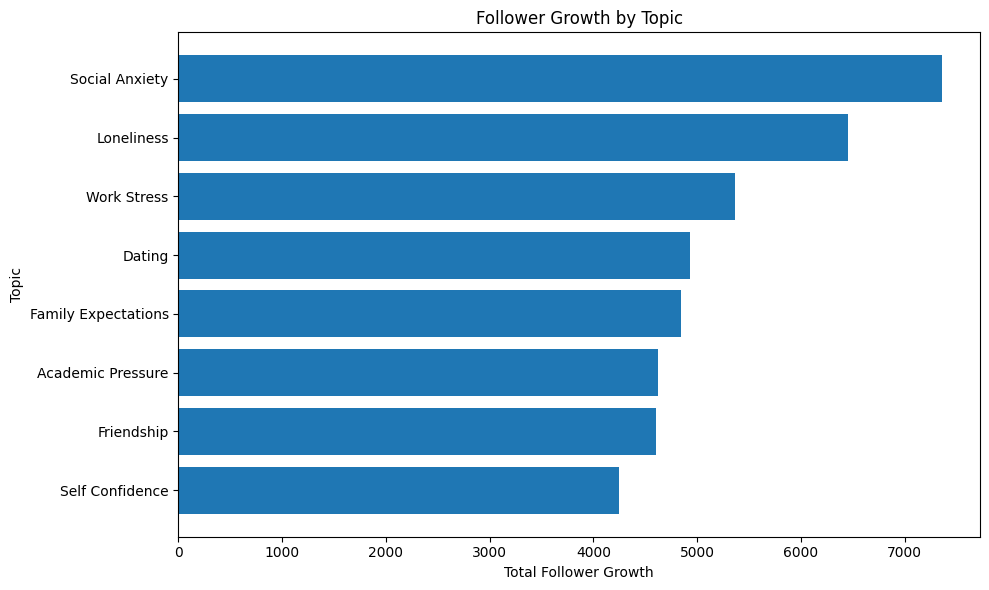

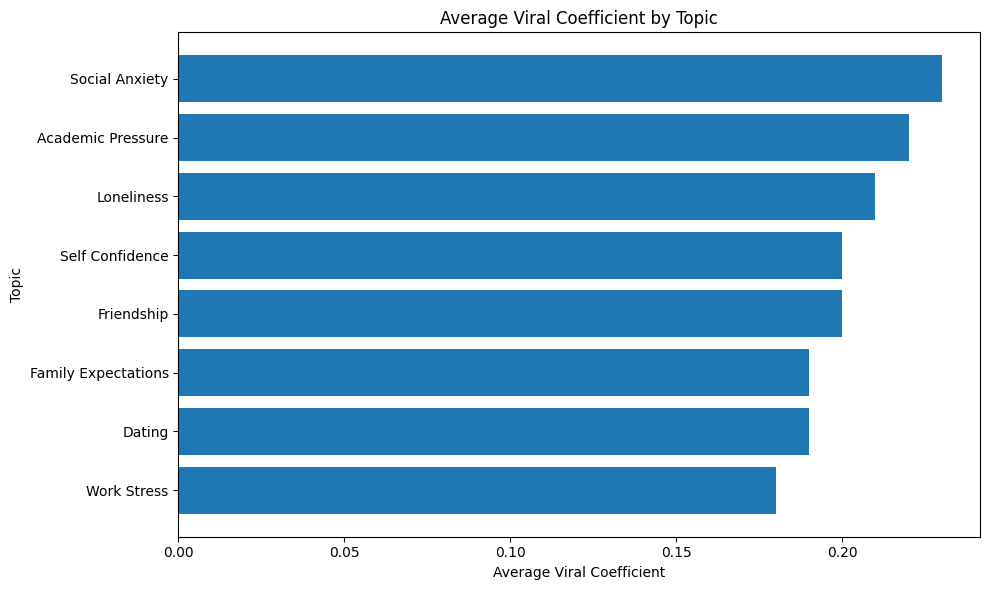

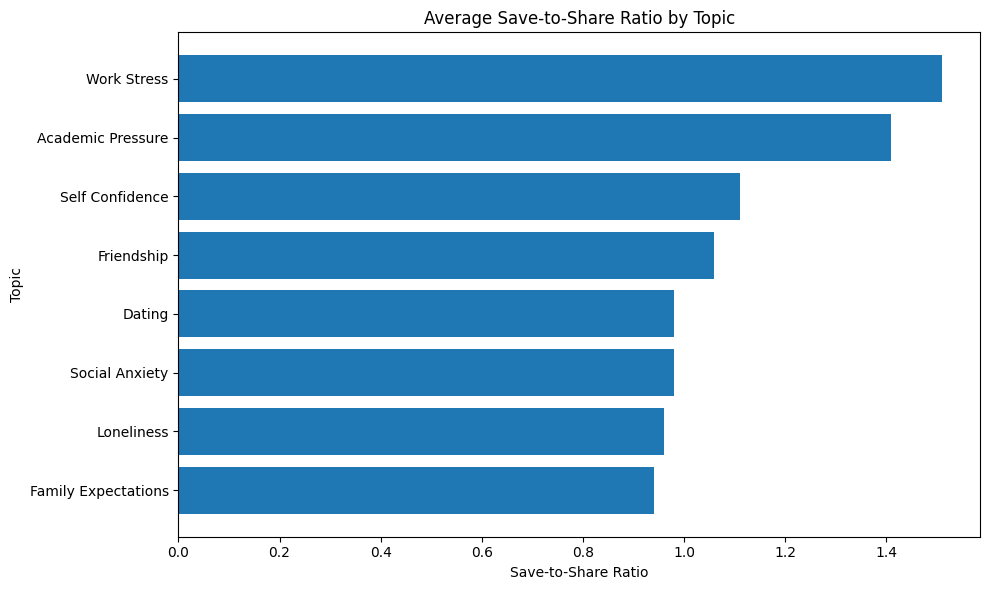

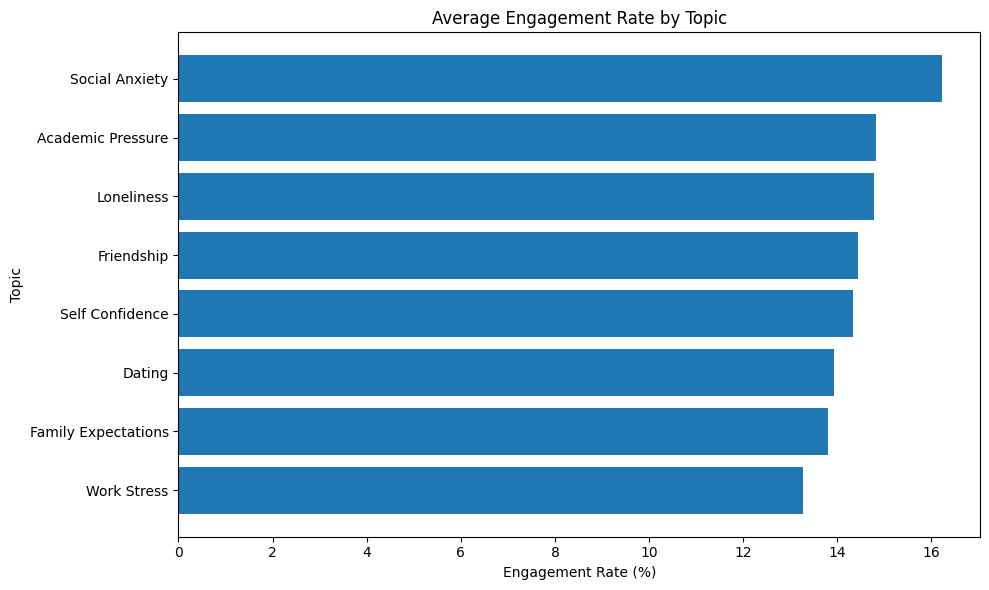

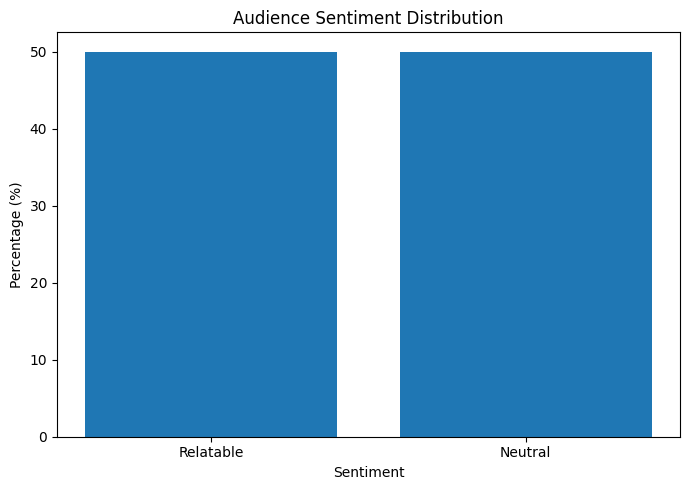

All dashboard visualizations generated successfully!


In [138]:
# STEP 16: Dashboard Visualizations

# 1. Follower Growth by Topic
plt.figure(figsize=(10, 6))

growth_data = dashboard_topic_summary.sort_values(
    "total_follower_growth"
)

plt.barh(
    growth_data["topic"],
    growth_data["total_follower_growth"]
)

plt.title("Follower Growth by Topic")
plt.xlabel("Total Follower Growth")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


# 2. Viral Coefficient by Topic
plt.figure(figsize=(10, 6))

viral_data = dashboard_topic_summary.sort_values(
    "average_viral_coefficient"
)

plt.barh(
    viral_data["topic"],
    viral_data["average_viral_coefficient"]
)

plt.title("Average Viral Coefficient by Topic")
plt.xlabel("Average Viral Coefficient")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


# 3. Save-to-Share Ratio by Topic
plt.figure(figsize=(10, 6))

ratio_data = dashboard_topic_summary.sort_values(
    "average_save_to_share_ratio"
)

plt.barh(
    ratio_data["topic"],
    ratio_data["average_save_to_share_ratio"]
)

plt.title("Average Save-to-Share Ratio by Topic")
plt.xlabel("Save-to-Share Ratio")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


# 4. Engagement Rate by Topic
plt.figure(figsize=(10, 6))

engagement_data = dashboard_topic_summary.sort_values(
    "average_engagement_rate"
)

plt.barh(
    engagement_data["topic"],
    engagement_data["average_engagement_rate"]
)

plt.title("Average Engagement Rate by Topic")
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


# 5. Audience Sentiment
plt.figure(figsize=(7, 5))

plt.bar(
    dashboard_sentiment_summary["sentiment"],
    dashboard_sentiment_summary["percentage"]
)

plt.title("Audience Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

print("All dashboard visualizations generated successfully!")

Trend Forecasting Results


,trend_rank,topic,average_engagement_rate,average_viral_coefficient,total_follower_growth,trend_score
0,1,Social Anxiety,16.22,0.23,7358,43.32
1,2,Loneliness,14.77,0.21,6450,38.53
2,3,Work Stress,13.26,0.18,5362,32.62
3,4,Dating,13.92,0.19,4933,31.49
4,5,Academic Pressure,14.82,0.22,4620,31.23
5,6,Family Expectations,13.80,0.19,4845,30.93
6,7,Friendship,14.44,0.20,4605,30.65
7,8,Self Confidence,14.33,0.20,4245,29.16


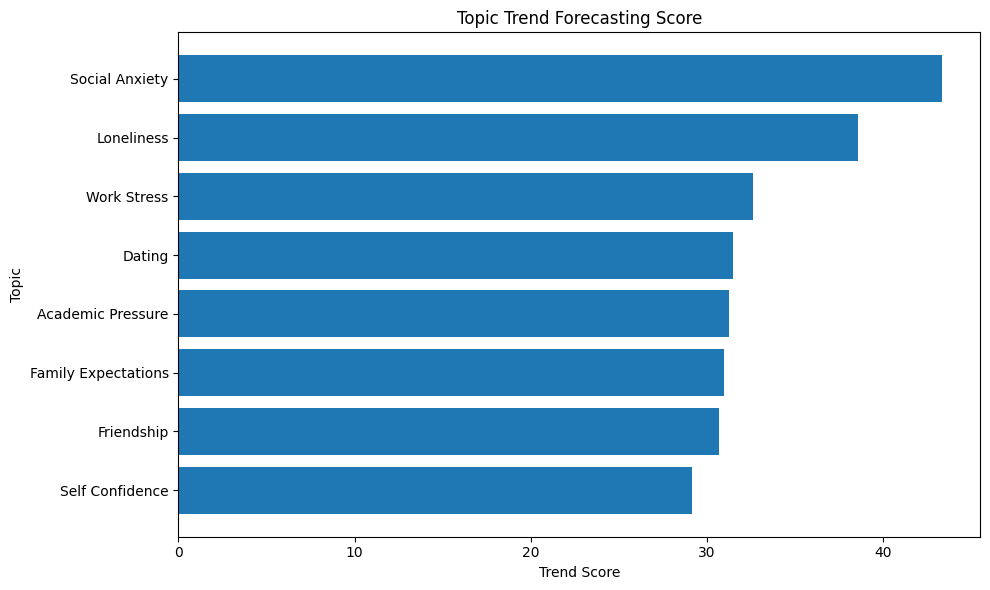


Trend forecasting results saved successfully!


In [139]:
# STEP 17: Trend Forecasting Prototype

# Aggregate topic-level performance
trend_df = clean_df.groupby("topic").agg({
    "engagement_rate": "mean",
    "viral_coefficient": "mean",
    "follower_growth": "sum",
    "reach": "sum"
}).reset_index()

trend_df = trend_df.rename(columns={
    "engagement_rate": "average_engagement_rate",
    "viral_coefficient": "average_viral_coefficient",
    "follower_growth": "total_follower_growth",
    "reach": "total_reach"
})

# Normalize follower growth
max_growth = trend_df["total_follower_growth"].max()

trend_df["growth_score"] = (
    trend_df["total_follower_growth"]
    / max_growth
) * 30

# Project-defined trend score
trend_df["trend_score"] = (
    trend_df["average_engagement_rate"] * 0.4
    + trend_df["average_viral_coefficient"] * 100 * 0.3
    + trend_df["growth_score"]
)

# Rank topics by trend score
trend_df = trend_df.sort_values(
    "trend_score",
    ascending=False
).reset_index(drop=True)

trend_df["trend_rank"] = (
    trend_df.index + 1
)

print("Trend Forecasting Results")
print("=========================")

display(
    trend_df[
        [
            "trend_rank",
            "topic",
            "average_engagement_rate",
            "average_viral_coefficient",
            "total_follower_growth",
            "trend_score"
        ]
    ].round(2)
)

# Visualization
plt.figure(figsize=(10, 6))

plot_data = trend_df.sort_values("trend_score")

plt.barh(
    plot_data["topic"],
    plot_data["trend_score"]
)

plt.title("Topic Trend Forecasting Score")
plt.xlabel("Trend Score")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

# Save results
trend_df.to_csv(
    "trend_forecasting_results.csv",
    index=False
)

print("\nTrend forecasting results saved successfully!")

In [140]:
# STEP 18: Final Analytics Summary

final_summary = pd.DataFrame({
    "Metric": [
        "Total Content Items",
        "Total Comments",
        "Average Reach",
        "Average Views",
        "Average Engagement Rate (%)",
        "Average Retention Rate (%)",
        "Average Viral Coefficient",
        "Total Follower Growth",
        "Relatable Comments (%)",
        "Neutral Comments (%)"
    ],
    "Value": [
        len(clean_df),
        len(comments_df),
        round(clean_df["reach"].mean(), 2),
        round(clean_df["views"].mean(), 2),
        round(clean_df["engagement_rate"].mean(), 2),
        round(clean_df["retention_rate"].mean(), 2),
        round(clean_df["viral_coefficient"].mean(), 4),
        int(clean_df["follower_growth"].sum()),
        round(
            (comments_df["label"] == "Relatable").mean() * 100,
            2
        ),
        round(
            (comments_df["label"] == "Neutral").mean() * 100,
            2
        )
    ]
})

print("FINAL ANALYTICS SUMMARY")
print("=======================")

display(final_summary)

# Save final summary
final_summary.to_csv(
    "final_analytics_summary.csv",
    index=False
)

print("\nFinal analytics summary saved successfully!")

FINAL ANALYTICS SUMMARY


,Metric,Value
0,Total Content Items,240.0000
1,Total Comments,480.0000
2,Average Reach,26400.4800
3,Average Views,23827.7600
4,Average Engagement Rate (%),14.5000
5,Average Retention Rate (%),63.8500
6,Average Viral Coefficient,0.2038
7,Total Follower Growth,42418.0000
8,Relatable Comments (%),50.0000
9,Neutral Comments (%),50.0000



Final analytics summary saved successfully!


In [141]:
# STEP 19: Create the Streamlit Dashboard

dashboard_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Social Engagement Analytics",
    layout="wide"
)

# Load datasets
content_df = pd.read_csv("final_content_analytics_dataset.csv")
topic_df = pd.read_csv("dashboard_topic_summary.csv")
sentiment_df = pd.read_csv("dashboard_sentiment_summary.csv")
recommendations_df = pd.read_csv("top_10_content_recommendations.csv")
trend_df = pd.read_csv("trend_forecasting_results.csv")

st.title("The Data-Driven Social Engagement Initiative")
st.write(
    "Analytics dashboard for content performance, virality, "
    "audience relatability, trends, and optimization."
)

# ---------------- KPI SECTION ----------------

st.header("Key Performance Indicators")

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Total Content",
    len(content_df)
)

col2.metric(
    "Average Reach",
    f"{content_df['reach'].mean():,.0f}"
)

col3.metric(
    "Average Engagement",
    f"{content_df['engagement_rate'].mean():.2f}%"
)

col4.metric(
    "Total Follower Growth",
    f"{content_df['follower_growth'].sum():,.0f}"
)

# ---------------- CONTENT PERFORMANCE ----------------

st.header("Content Performance by Topic")

st.dataframe(
    topic_df,
    use_container_width=True
)

# Follower growth chart
fig, ax = plt.subplots(figsize=(10, 5))

growth_data = topic_df.sort_values(
    "total_follower_growth"
)

ax.barh(
    growth_data["topic"],
    growth_data["total_follower_growth"]
)

ax.set_title("Follower Growth by Topic")
ax.set_xlabel("Total Follower Growth")
ax.set_ylabel("Topic")

st.pyplot(fig)

# ---------------- VIRALITY ----------------

st.header("Virality Analysis")

fig, ax = plt.subplots(figsize=(10, 5))

viral_data = topic_df.sort_values(
    "average_viral_coefficient"
)

ax.barh(
    viral_data["topic"],
    viral_data["average_viral_coefficient"]
)

ax.set_title("Average Viral Coefficient by Topic")
ax.set_xlabel("Viral Coefficient")
ax.set_ylabel("Topic")

st.pyplot(fig)

# ---------------- SENTIMENT ----------------

st.header("Audience Sentiment")

st.dataframe(
    sentiment_df,
    use_container_width=True
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    sentiment_df["sentiment"],
    sentiment_df["percentage"]
)

ax.set_title("Audience Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Percentage (%)")

st.pyplot(fig)

# ---------------- SAVE TO SHARE ----------------

st.header("Save-to-Share Ratio")

fig, ax = plt.subplots(figsize=(10, 5))

ratio_data = topic_df.sort_values(
    "average_save_to_share_ratio"
)

ax.barh(
    ratio_data["topic"],
    ratio_data["average_save_to_share_ratio"]
)

ax.set_title("Average Save-to-Share Ratio by Topic")
ax.set_xlabel("Save-to-Share Ratio")
ax.set_ylabel("Topic")

st.pyplot(fig)

# ---------------- TREND FORECASTING ----------------

st.header("Trend Forecasting")

st.dataframe(
    trend_df,
    use_container_width=True
)

fig, ax = plt.subplots(figsize=(10, 5))

trend_plot = trend_df.sort_values(
    "trend_score"
)

ax.barh(
    trend_plot["topic"],
    trend_plot["trend_score"]
)

ax.set_title("Topic Trend Forecasting Score")
ax.set_xlabel("Trend Score")
ax.set_ylabel("Topic")

st.pyplot(fig)

# ---------------- RECOMMENDATIONS ----------------

st.header("Content Optimization Recommendations")

st.dataframe(
    recommendations_df,
    use_container_width=True
)

st.success(
    "Dashboard analysis completed successfully."
)

# ---------------- RAW DATA ----------------

st.header("Final Analytics Dataset")

st.dataframe(
    content_df,
    use_container_width=True
)
'''

with open("social_engagement_dashboard.py", "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("Dashboard file created successfully!")
print("File name: social_engagement_dashboard.py")

Dashboard file created successfully!
File name: social_engagement_dashboard.py


In [142]:
# STEP 20: Install Streamlit

!pip install -q streamlit

print("Streamlit installation completed!")

Streamlit installation completed!


In [143]:
# STEP 22: Run Streamlit and create a Colab-accessible link

import subprocess
import time
from google.colab.output import eval_js

# Start Streamlit in the background
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "social_engagement_dashboard.py",
        "--server.port=8501",
        "--server.headless=true"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Give Streamlit time to start
time.sleep(5)

# Create the Colab proxy link
url = eval_js("google.colab.kernel.proxyPort(8501)")

print("========================================")
print("STREAMLIT DASHBOARD IS READY!")
print("========================================")
print("Open this link:")
print(url)

STREAMLIT DASHBOARD IS READY!
Open this link:
https://8501-m-s-kkb-usc1b2-31bokfa4dc2px-b.us-central1-2.prod.colab.dev


In [144]:
# STEP 23: Check whether Streamlit is actually responding

!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Wed, 30 Sep 2026 17:48:41 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Wed, 30 Sep 2026 14:59:58 GMT
etag: "50d4468876e9552988bae6293f98c3ff"
cache-control: no-cache



In [145]:
!pkill -f "streamlit run" || true
print("Old Streamlit process stopped.")

^C
Old Streamlit process stopped.


In [146]:
import subprocess
import time
from google.colab.output import eval_js

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "social_engagement_dashboard.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.enableWebsocketCompression=false"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

url = eval_js("google.colab.kernel.proxyPort(8501)")

print("DASHBOARD URL:")
print(url)

DASHBOARD URL:
https://8501-m-s-kkb-usc1b2-31bokfa4dc2px-b.us-central1-2.prod.colab.dev


In [147]:
import shutil

shutil.copy(
    "social_engagement_dashboard.py",
    "social_engagement_dashboard_BACKUP.py"
)

print("✅ Backup created: social_engagement_dashboard_BACKUP.py")
print("Your original working dashboard is safe.")

✅ Backup created: social_engagement_dashboard_BACKUP.py
Your original working dashboard is safe.


In [148]:
# Add an interactive explorer to the existing dashboard
with open("social_engagement_dashboard.py", "a") as f:
    f.write(r'''

# ============================================================
# INTERACTIVE CONTENT EXPLORER
# ============================================================

st.divider()
st.header("🔎 Interactive Content Explorer")
st.write("Use the filters below to explore the content performance dataset.")

# Load the final dataset independently so the existing dashboard remains unchanged
interactive_df = pd.read_csv("final_content_analytics_dataset.csv")

# Sidebar filters
st.sidebar.divider()
st.sidebar.header("🎛️ Dashboard Filters")

selected_topic = st.sidebar.selectbox(
    "Select Topic",
    ["All"] + sorted(interactive_df["topic"].unique().tolist())
)

selected_format = st.sidebar.selectbox(
    "Select Format",
    ["All"] + sorted(interactive_df["format"].unique().tolist())
)

selected_posting_time = st.sidebar.selectbox(
    "Select Posting Time",
    ["All"] + sorted(interactive_df["posting_time"].unique().tolist())
)

# Apply filters
filtered_df = interactive_df.copy()

if selected_topic != "All":
    filtered_df = filtered_df[filtered_df["topic"] == selected_topic]

if selected_format != "All":
    filtered_df = filtered_df[filtered_df["format"] == selected_format]

if selected_posting_time != "All":
    filtered_df = filtered_df[
        filtered_df["posting_time"] == selected_posting_time
    ]

# Interactive KPIs
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Content Items", len(filtered_df))

with col2:
    st.metric(
        "Average Reach",
        f"{filtered_df['reach'].mean():,.0f}" if len(filtered_df) else "0"
    )

with col3:
    st.metric(
        "Avg Engagement",
        f"{filtered_df['engagement_rate'].mean():.2f}%"
        if len(filtered_df) else "0%"
    )

with col4:
    st.metric(
        "Follower Growth",
        f"{filtered_df['follower_growth'].sum():,.0f}"
        if len(filtered_df) else "0"
    )

# Interactive table
st.subheader("Filtered Content Performance")

st.dataframe(
    filtered_df[
        [
            "content_id",
            "topic",
            "format",
            "hook_type",
            "posting_time",
            "caption_style",
            "reach",
            "views",
            "likes",
            "comments",
            "shares",
            "saves",
            "engagement_rate",
            "viral_coefficient",
            "follower_growth"
        ]
    ],
    use_container_width=True,
    hide_index=True
)

# Interactive charts
if len(filtered_df) > 0:

    st.subheader("Filtered Engagement by Topic")

    topic_chart = (
        filtered_df.groupby("topic")["engagement_rate"]
        .mean()
        .sort_values(ascending=False)
    )

    st.bar_chart(topic_chart)

    st.subheader("Filtered Follower Growth")

    growth_chart = (
        filtered_df.groupby("topic")["follower_growth"]
        .sum()
        .sort_values(ascending=False)
    )

    st.bar_chart(growth_chart)

    st.subheader("Filtered Virality")

    viral_chart = (
        filtered_df.groupby("topic")["viral_coefficient"]
        .mean()
        .sort_values(ascending=False)
    )

    st.bar_chart(viral_chart)

else:
    st.warning("No content matches the selected filters.")

''')

print("✅ Interactive explorer added to the existing dashboard.")
print("✅ Original dashboard code was not replaced.")

✅ Interactive explorer added to the existing dashboard.
✅ Original dashboard code was not replaced.


In [149]:
!pkill -f "streamlit run" || true

import subprocess
import time
from google.colab.output import eval_js

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "social_engagement_dashboard.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.enableWebsocketCompression=false"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

url = eval_js("google.colab.kernel.proxyPort(8501)")

print("DASHBOARD URL:")
print(url)

^C
DASHBOARD URL:
https://8501-m-s-kkb-usc1b2-31bokfa4dc2px-b.us-central1-2.prod.colab.dev


In [150]:
import shutil

shutil.copy(
    "social_engagement_dashboard_BACKUP.py",
    "social_engagement_dashboard.py"
)

print("✅ Original working dashboard restored.")
print("The backup remains untouched.")

✅ Original working dashboard restored.
The backup remains untouched.


In [151]:
# ============================================================
# REBUILD THE DASHBOARD WITH REAL INTERACTIVE FILTERS
# ============================================================

dashboard_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Social Engagement Analytics",
    page_icon="📊",
    layout="wide"
)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("final_content_analytics_dataset.csv")
sentiment_df = pd.read_csv("dashboard_sentiment_summary.csv")
trend_df = pd.read_csv("trend_forecasting_results.csv")
recommendations_df = pd.read_csv("top_10_content_recommendations.csv")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

st.title("📊 The Data-Driven Social Engagement Initiative")
st.write(
    "Interactive analytics dashboard for content performance, "
    "virality, audience sentiment, growth, trends and optimization."
)

# ------------------------------------------------------------
# SIDEBAR FILTERS
# ------------------------------------------------------------

st.sidebar.header("🎛️ Dashboard Filters")

topic_options = ["All"] + sorted(df["topic"].dropna().unique().tolist())
format_options = ["All"] + sorted(df["format"].dropna().unique().tolist())
posting_options = ["All"] + sorted(df["posting_time"].dropna().unique().tolist())
hook_options = ["All"] + sorted(df["hook_type"].dropna().unique().tolist())

selected_topic = st.sidebar.selectbox(
    "Topic",
    topic_options
)

selected_format = st.sidebar.selectbox(
    "Format",
    format_options
)

selected_posting_time = st.sidebar.selectbox(
    "Posting Time",
    posting_options
)

selected_hook = st.sidebar.selectbox(
    "Hook Type",
    hook_options
)

# ------------------------------------------------------------
# APPLY FILTERS
# ------------------------------------------------------------

filtered_df = df.copy()

if selected_topic != "All":
    filtered_df = filtered_df[
        filtered_df["topic"] == selected_topic
    ]

if selected_format != "All":
    filtered_df = filtered_df[
        filtered_df["format"] == selected_format
    ]

if selected_posting_time != "All":
    filtered_df = filtered_df[
        filtered_df["posting_time"] == selected_posting_time
    ]

if selected_hook != "All":
    filtered_df = filtered_df[
        filtered_df["hook_type"] == selected_hook
    ]

# ------------------------------------------------------------
# ACTIVE FILTER MESSAGE
# ------------------------------------------------------------

active_filters = []

if selected_topic != "All":
    active_filters.append(f"Topic: {selected_topic}")

if selected_format != "All":
    active_filters.append(f"Format: {selected_format}")

if selected_posting_time != "All":
    active_filters.append(f"Posting Time: {selected_posting_time}")

if selected_hook != "All":
    active_filters.append(f"Hook: {selected_hook}")

if active_filters:
    st.info("Active filters → " + " | ".join(active_filters))
else:
    st.info("Showing all content.")

# ------------------------------------------------------------
# KPI SECTION
# ------------------------------------------------------------

st.header("📌 Key Performance Indicators")

col1, col2, col3, col4 = st.columns(4)

if len(filtered_df) > 0:

    total_content = len(filtered_df)
    avg_reach = filtered_df["reach"].mean()
    avg_engagement = filtered_df["engagement_rate"].mean()
    total_followers = filtered_df["follower_growth"].sum()

else:

    total_content = 0
    avg_reach = 0
    avg_engagement = 0
    total_followers = 0

with col1:
    st.metric(
        "Content Items",
        f"{total_content:,}"
    )

with col2:
    st.metric(
        "Average Reach",
        f"{avg_reach:,.0f}"
    )

with col3:
    st.metric(
        "Average Engagement",
        f"{avg_engagement:.2f}%"
    )

with col4:
    st.metric(
        "Follower Growth",
        f"{total_followers:,.0f}"
    )

# ------------------------------------------------------------
# TOPIC PERFORMANCE
# ------------------------------------------------------------

st.header("📈 Content Performance")

if len(filtered_df) > 0:

    topic_summary = (
        filtered_df
        .groupby("topic")
        .agg(
            Content=("content_id", "count"),
            Reach=("reach", "mean"),
            Views=("views", "mean"),
            Likes=("likes", "mean"),
            Comments=("comments", "mean"),
            Shares=("shares", "mean"),
            Saves=("saves", "mean"),
            Engagement_Rate=("engagement_rate", "mean"),
            Viral_Coefficient=("viral_coefficient", "mean"),
            Follower_Growth=("follower_growth", "sum")
        )
        .reset_index()
    )

    st.dataframe(
        topic_summary,
        use_container_width=True,
        hide_index=True
    )

else:

    st.warning("No content matches the selected filters.")

# ------------------------------------------------------------
# CHARTS
# ------------------------------------------------------------

if len(filtered_df) > 0:

    tab1, tab2, tab3, tab4 = st.tabs(
        [
            "📈 Engagement",
            "🚀 Virality",
            "👥 Growth",
            "💾 Saves vs Shares"
        ]
    )

    # --------------------------------------------------------
    # ENGAGEMENT
    # --------------------------------------------------------

    with tab1:

        engagement_data = (
            filtered_df
            .groupby("topic")["engagement_rate"]
            .mean()
            .sort_values(ascending=False)
        )

        st.subheader("Average Engagement Rate by Topic")
        st.bar_chart(engagement_data)

    # --------------------------------------------------------
    # VIRALITY
    # --------------------------------------------------------

    with tab2:

        viral_data = (
            filtered_df
            .groupby("topic")["viral_coefficient"]
            .mean()
            .sort_values(ascending=False)
        )

        st.subheader("Average Viral Coefficient by Topic")
        st.bar_chart(viral_data)

    # --------------------------------------------------------
    # FOLLOWER GROWTH
    # --------------------------------------------------------

    with tab3:

        growth_data = (
            filtered_df
            .groupby("topic")["follower_growth"]
            .sum()
            .sort_values(ascending=False)
        )

        st.subheader("Follower Growth by Topic")
        st.bar_chart(growth_data)

    # --------------------------------------------------------
    # SAVE TO SHARE
    # --------------------------------------------------------

    with tab4:

        save_share = filtered_df.copy()

        save_share["save_to_share_ratio"] = (
            save_share["saves"] /
            save_share["shares"].replace(0, pd.NA)
        )

        ratio_data = (
            save_share
            .groupby("topic")["save_to_share_ratio"]
            .mean()
            .sort_values(ascending=False)
        )

        st.subheader("Save-to-Share Ratio by Topic")
        st.bar_chart(ratio_data)

# ------------------------------------------------------------
# AUDIENCE SENTIMENT
# ------------------------------------------------------------

st.header("💬 Audience Sentiment")

st.dataframe(
    sentiment_df,
    use_container_width=True,
    hide_index=True
)

# ------------------------------------------------------------
# TREND FORECASTING
# ------------------------------------------------------------

st.header("🔮 Trend Forecasting")

st.dataframe(
    trend_df,
    use_container_width=True,
    hide_index=True
)

if "topic" in trend_df.columns and "trend_score" in trend_df.columns:

    trend_chart = (
        trend_df
        .set_index("topic")["trend_score"]
        .sort_values(ascending=False)
    )

    st.subheader("Trend Score by Topic")
    st.bar_chart(trend_chart)

# ------------------------------------------------------------
# CONTENT OPTIMIZATION
# ------------------------------------------------------------

st.header("🎯 Content Optimization Recommendations")

st.write(
    "Recommended content combinations based on the project's "
    "virality and success-probability model."
)

st.dataframe(
    recommendations_df,
    use_container_width=True,
    hide_index=True
)

# ------------------------------------------------------------
# FILTERED RAW DATA
# ------------------------------------------------------------

st.header("🗂️ Filtered Content Dataset")

st.dataframe(
    filtered_df,
    use_container_width=True,
    hide_index=True
)

# ------------------------------------------------------------
# DOWNLOAD
# ------------------------------------------------------------

if len(filtered_df) > 0:

    csv_data = filtered_df.to_csv(index=False)

    st.download_button(
        label="⬇️ Download Filtered Dataset",
        data=csv_data,
        file_name="filtered_content_performance.csv",
        mime="text/csv"
    )

st.divider()

st.caption(
    "The dashboard uses the project-generated analytical dataset "
    "created for this prototype."
)
'''

with open("social_engagement_dashboard.py", "w") as f:
    f.write(dashboard_code)

print("✅ New interactive dashboard code created.")
print("✅ Original dashboard remains محفوظ in social_engagement_dashboard_BACKUP.py")
print("✅ Filters now control the KPIs, tables and charts.")
print("✅ Tabs added for Engagement, Virality, Growth and Save-to-Share.")
print("✅ Download button added.")

✅ New interactive dashboard code created.
✅ Original dashboard remains محفوظ in social_engagement_dashboard_BACKUP.py
✅ Filters now control the KPIs, tables and charts.
✅ Tabs added for Engagement, Virality, Growth and Save-to-Share.
✅ Download button added.


In [152]:
!pkill -f "streamlit run" || true

import subprocess
import time
from google.colab.output import eval_js

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "social_engagement_dashboard.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
        "--server.enableWebsocketCompression=false"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

url = eval_js("google.colab.kernel.proxyPort(8501)")

print("✅ INTERACTIVE DASHBOARD IS RUNNING")
print()
print("OPEN THIS URL:")
print(url)

^C
✅ INTERACTIVE DASHBOARD IS RUNNING

OPEN THIS URL:
https://8501-m-s-kkb-usc1b2-31bokfa4dc2px-b.us-central1-2.prod.colab.dev
